Dataset from Kaggle : "Titanic - Machine Learning from Disaster"
Source: https://www.kaggle.com/competitions/titanic/overview

Essential Libraries
Let us begin by importing the essential Python Libraries.

NumPy : Library for Numeric Computations in Python
Pandas : Library for Data Acquisition and Preparation
Matplotlib : Low-level library for Data Visualization
Seaborn : Higher-level library for Data Visualization

In [21]:
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() 

Import data set

In [27]:
data = pd.read_csv("train.csv")
print(data.shape)
data.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Show important data

In [28]:
print("Shape:", data.shape)
print(data.dtypes)

Shape: (891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [29]:
data.describe(include = "all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [30]:
print(pd.isnull(data).sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Survived
0           549
1           342
Name: count, dtype: int64


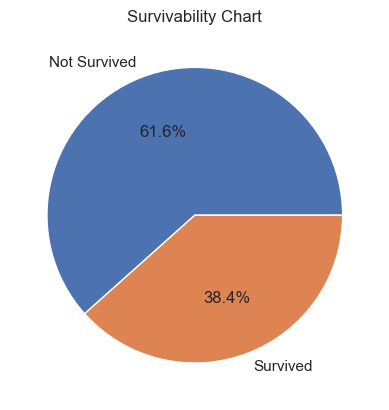

In [31]:
survived = pd.DataFrame(data['Survived'])
print( survived.value_counts())
plt.pie(
    survived.value_counts(),
    labels=['Not Survived', 'Survived'],
    autopct='%1.1f%%',
)
plt.title("Survivability Chart")
plt.show()

Survivability statistic

Text(0.5, 1.0, 'Age histogram')

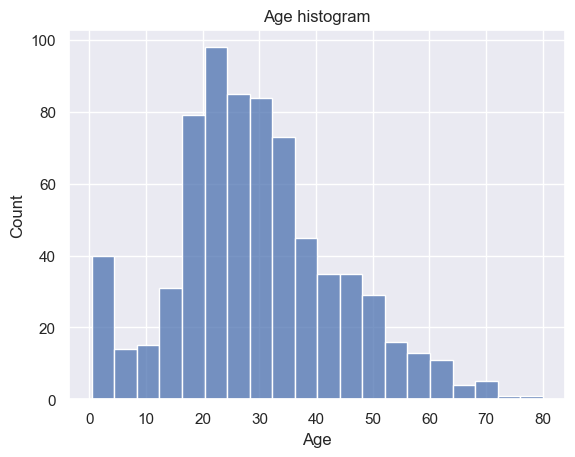

In [32]:
sb.histplot(data = data["Age"])
plt.title("Age histogram")

     Survived   Age
0           0  22.0
1           1  38.0
2           1  26.0
3           1  35.0
4           0  35.0
..        ...   ...
886         0  27.0
887         1  19.0
888         0   NaN
889         1  26.0
890         0  32.0

[891 rows x 2 columns]


<Axes: >

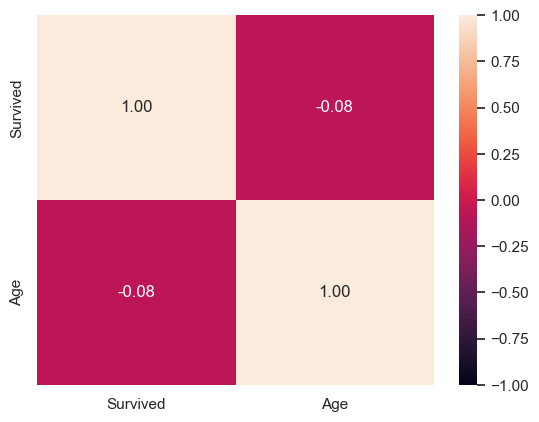

In [33]:
jointAge = pd.concat([survived, data["Age"]], axis = 1)
print(jointAge)
sb.heatmap(jointAge.corr(), vmin = -1, vmax = 1, annot = True, fmt=".2f")

Pclass
3         491
1         216
2         184
Name: count, dtype: int64


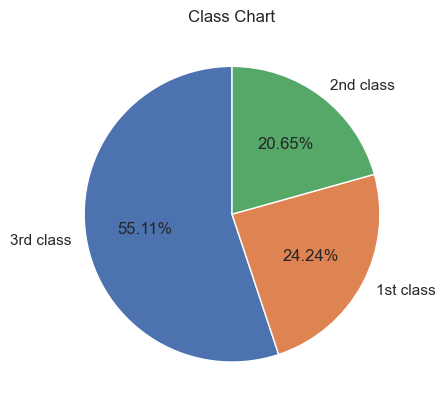

In [34]:
Pclass = pd.DataFrame(data['Pclass'])
print(Pclass.value_counts())
plt.pie(
    Pclass.value_counts(), 
    labels = ["3rd class", "1st class", "2nd class"], 
    autopct='%1.2f%%',
    startangle = 90
)
plt.title("Class Chart")
plt.show()

Text(0.5, 1.0, 'Survivability by classes')

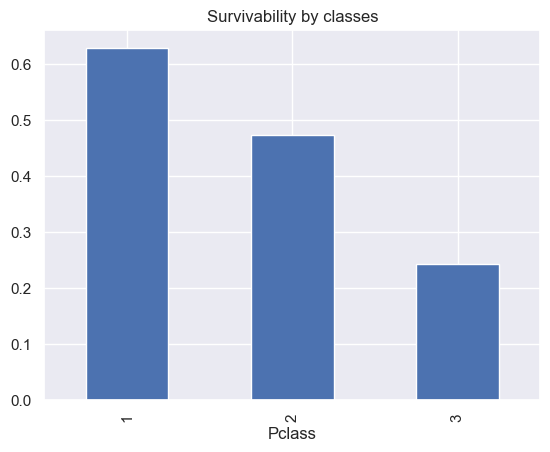

In [35]:
class_rate = data.groupby("Pclass")["Survived"].mean()
class_rate.plot(kind = "bar")
plt.title("Survivability by classes")

     Survived  Pclass
0           0       3
1           1       1
2           1       3
3           1       1
4           0       3
..        ...     ...
886         0       2
887         1       1
888         0       3
889         1       1
890         0       3

[891 rows x 2 columns]


<Axes: >

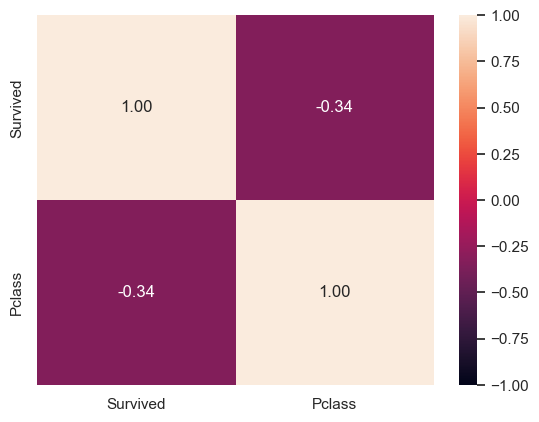

In [36]:
jointClass = pd.concat([survived, Pclass], axis = 1)
print(jointClass)
sb.heatmap(jointClass.corr(), vmin = -1, vmax = 1, annot = True, fmt=".2f")

     Survived     Fare
0           0   7.2500
1           1  71.2833
2           1   7.9250
3           1  53.1000
4           0   8.0500
..        ...      ...
886         0  13.0000
887         1  30.0000
888         0  23.4500
889         1  30.0000
890         0   7.7500

[891 rows x 2 columns]


<Axes: >

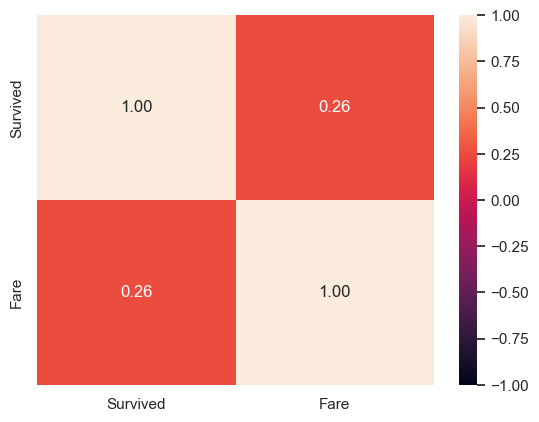

In [48]:
jointFare = pd.DataFrame(data[["Survived","Fare"]])
print(jointFare)
sb.heatmap(jointFare.corr(), vmin = -1, vmax = 1, annot = True, fmt=".2f")

Text(0.5, 1.0, 'Survivability by gender')

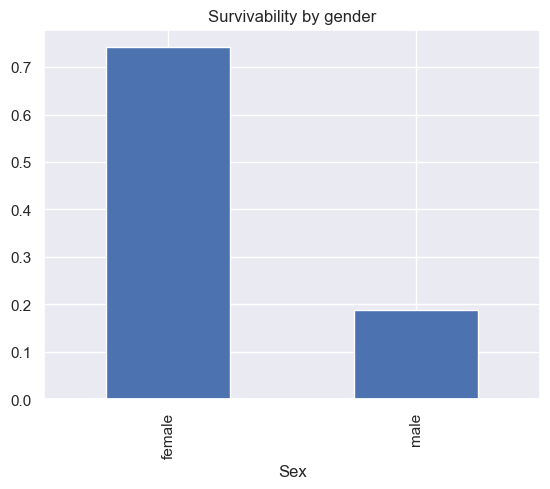

In [37]:
gender_rate = data.groupby("Sex")["Survived"].mean()
gender_rate.plot(kind = "bar")
plt.title("Survivability by gender")

Text(0.5, 1.0, 'Survivability by the number of Siblings')

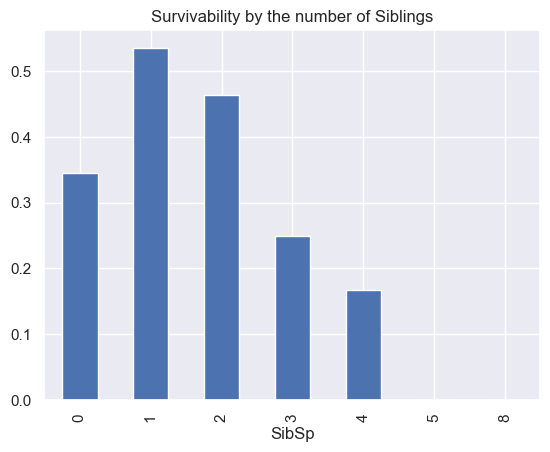

In [38]:
sib_rate = data.groupby("SibSp")["Survived"].mean()
sib_rate.plot(kind = "bar")
plt.title("Survivability by the number of Siblings")

<Axes: >

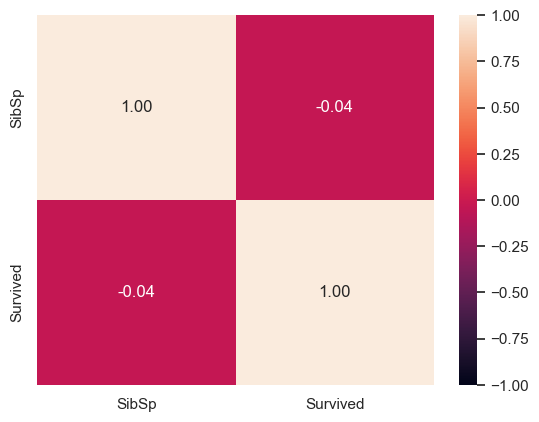

In [39]:
jointSib = pd.concat([data['SibSp'], data['Survived']],axis = 1)
sb.heatmap(jointSib.corr(), vmin = -1, vmax = 1, annot = True, fmt = '.2f')

Text(0.5, 1.0, 'Survivability by the number of Parents/Children')

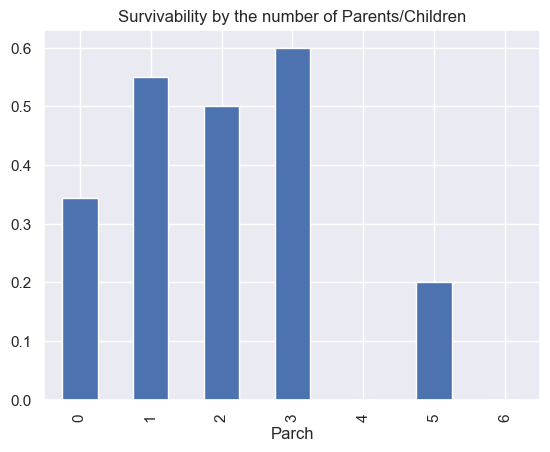

In [40]:
parch_rate = data.groupby("Parch")["Survived"].mean()
parch_rate.plot(kind = "bar")
plt.title("Survivability by the number of Parents/Children")

<Axes: >

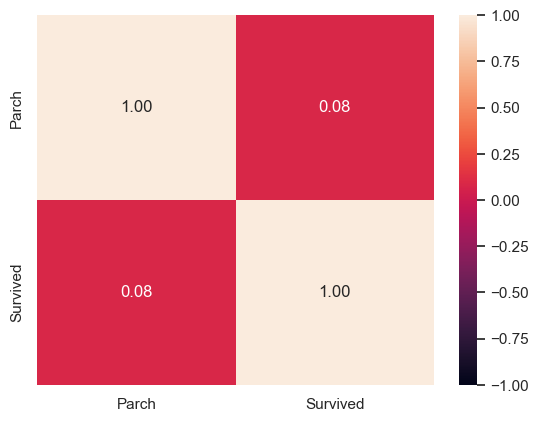

In [41]:
jointParch = pd.concat([data['Parch'], data['Survived']],axis = 1)
sb.heatmap(jointParch.corr(), vmin = -1, vmax = 1, annot = True, fmt = '.2f')

In [42]:
data["Age"] = data["Age"].fillna(-0.5)

bins = [-1, 0, 5, 12, 18, 24, 35, 60, np.inf]
labels = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Senior']

data["Age Group"] = pd.cut(data["Age"], bins, labels = labels)

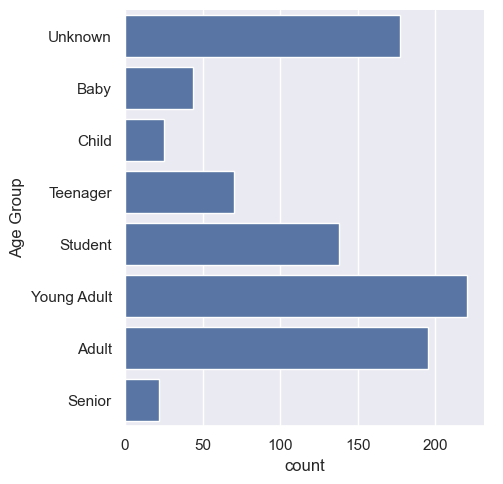

In [43]:
sb.catplot(y = "Age Group", data = data, kind = "count")

C:\Users\admin\AppData\Local\Temp\ipykernel_6372\4012166374.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  parch_rate = data.groupby("Age Group")["Survived"].mean()


Text(0.5, 1.0, 'Survivability by age group')

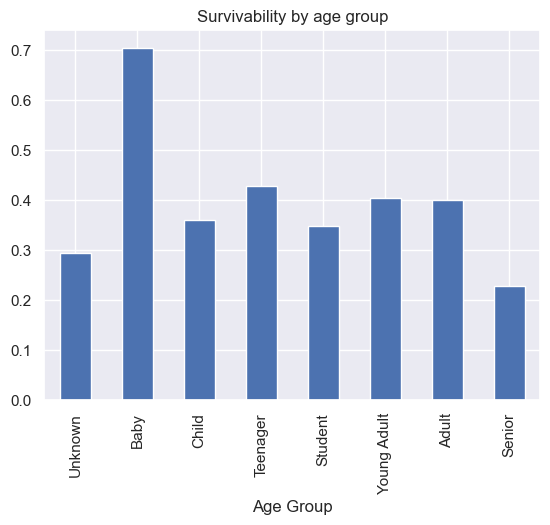

In [44]:
parch_rate = data.groupby("Age Group")["Survived"].mean()
parch_rate.plot(kind = "bar")
plt.title("Survivability by age group")

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [55]:
Y = pd.DataFrame(data["Survived"])
X = pd.DataFrame(data[["Pclass", "Sex", "SibSp", "Fare", "Age Group"]])
X.head()

,Pclass,Sex,SibSp,Fare,Age Group
0,3,male,1,7.2500,Student
1,1,female,1,71.2833,Adult
2,3,female,0,7.9250,Young Adult
3,1,female,1,53.1000,Young Adult
4,3,male,0,8.0500,Young Adult


In [66]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
X['Sex'] = label_encoder.fit_transform(X['Sex'])
X['Age Group'] = label_encoder.fit_transform(X['Age Group'])

In [67]:
X.head()

,Pclass,Sex,SibSp,Fare,Age Group
0,3,1,1,7.2500,4
1,1,0,1,71.2833,0
2,3,0,0,7.9250,7
3,1,0,1,53.1000,7
4,3,1,0,8.0500,7


In [68]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25)

print("Train Set :", Y_train.shape, X_train.shape)
print("Test Set  :", Y_test.shape, X_test.shape)

Train Set : (668, 1) (668, 5)
Test Set  : (223, 1) (223, 5)


In [75]:
dectree = DecisionTreeClassifier(max_depth = 6)  # create the decision tree object
dectree.fit(X_train, Y_train)                    # train the decision tree model

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [76]:
import graphviz as gp
#print package version
print("Graphviz version = "+gp.__version__)

Graphviz version = 0.16


In [77]:
from sklearn.tree import export_graphviz

treedot = export_graphviz(dectree,                                      # the model
                          feature_names = X_train.columns.tolist(),              # the features 
                          out_file = None,                              # output file
                          filled = True,                                # node colors
                          rounded = True,                               # make pretty
                          special_characters = True)                    # postscript

# Render using graphviz
#import os
#os.environ["PATH"] += os.pathsep + 'C:/Program Files (x86)/Graphviz2.38/bin/'
import graphviz
graphviz.Source(treedot)

CalledProcessError: Command '['dot.bat', '-Kdot', '-Tsvg']' returned non-zero exit status 3221225477. [stderr: b'Warning: Could not load "C:\\Users\\admin\\miniconda3\\envs\\ie0005\\Library\\bin\\gvplugin_pango.dll" - It was found, so perhaps one of its dependents was not.  Try ldd.\r\nWarning: Warning: no value for width of non-ASCII character 226. Falling back to width of space character\r\n']

Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.8667664670658682

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.7623318385650224



<Axes: >

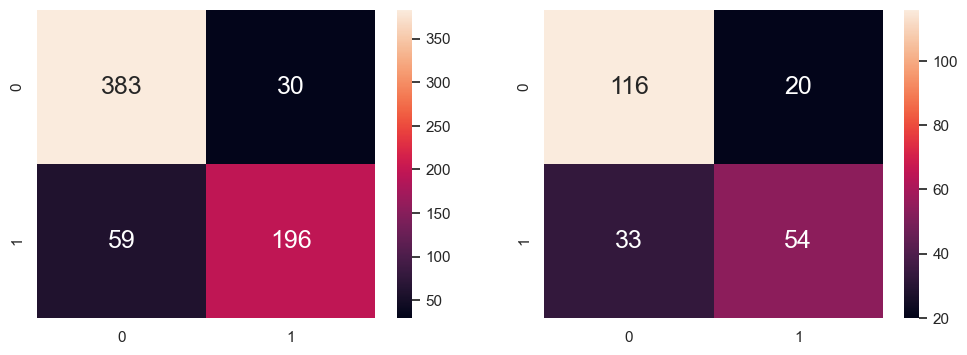

In [80]:
Y_train_pred = dectree.predict(X_train)
Y_test_pred = dectree.predict(X_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", dectree.score(X_train, Y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", dectree.score(X_test, Y_test))
print()

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(Y_train, Y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(Y_test, Y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])

In [84]:
# Gradient Boosting Classifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier

gbk = GradientBoostingClassifier()
gbk.fit(X_train, Y_train)
Y_pred = gbk.predict(X_test)

acc_gbk = round(accuracy_score(Y_pred, Y_test) * 100, 2)
print(acc_gbk)

C:\Users\admin\miniconda3\envs\ie0005\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


77.13
